# Task 4: Disease Prediction from Medical Data

**Objective:** Predict the possibility of disease based on patient data.
**Approach:** Classification techniques applied to structured medical datasets.

**Datasets:** Breast Cancer (Wisconsin), Heart Disease (Cleveland), Diabetes (Pima Indians) — all from the UCI ML Repository.

**Algorithms:** Logistic Regression, SVM, Random Forest, XGBoost.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load Datasets

In [2]:
# Breast Cancer (built into sklearn, same data as UCI)
data = load_breast_cancer(as_frame=True)
bc_df = data.frame
X_bc, y_bc = bc_df.drop(columns=["target"]), bc_df["target"]
bc_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Heart Disease (UCI Cleveland)
heart_df = pd.read_csv("data/heart.csv")
heart_df.columns = [c.strip().lower() for c in heart_df.columns]
X_heart, y_heart = heart_df.drop(columns=["target"]), heart_df["target"]
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Diabetes (Pima Indians)
cols = ["pregnancies", "glucose", "blood_pressure", "skin_thickness",
        "insulin", "bmi", "diabetes_pedigree", "age", "outcome"]
diab_df = pd.read_csv("data/diabetes.csv", names=cols)

# 0s in these columns are placeholders for missing data -> impute with median
zero_as_missing = ["glucose", "blood_pressure", "skin_thickness", "insulin", "bmi"]
for col in zero_as_missing:
    diab_df[col] = diab_df[col].replace(0, np.nan)
    diab_df[col] = diab_df[col].fillna(diab_df[col].median())

X_diab, y_diab = diab_df.drop(columns=["outcome"]), diab_df["outcome"]
diab_df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 2. Reusable training + evaluation function

In [5]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(n_estimators=300, use_label_encoder=False,
                                  eval_metric="logloss", random_state=RANDOM_STATE),
    }

def run_pipeline(X, y, name):
    print(f"\n===== {name} (samples={X.shape[0]}, features={X.shape[1]}) =====")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    results, fitted = [], {}
    for mname, model in get_models().items():
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
        y_proba = model.predict_proba(X_test_s)[:, 1]
        results.append({
            "Model": mname,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        })
        fitted[mname] = model

    results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
    print(results_df.round(3).to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    fig.suptitle(f"Confusion Matrices — {name}", fontsize=14, fontweight="bold")
    for ax, (mname, model) in zip(axes.ravel(), fitted.items()):
        cm = confusion_matrix(y_test, model.predict(X_test_s))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
        ax.set_title(mname); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.show()

    return results_df.assign(Dataset=name), fitted, scaler

## 3. Run on each dataset


===== Breast Cancer (samples=569, features=30) =====


              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.982      0.986   0.986     0.986    0.995
                SVM     0.982      0.986   0.986     0.986    0.995
            XGBoost     0.956      0.947   0.986     0.966    0.993
      Random Forest     0.947      0.958   0.958     0.958    0.994


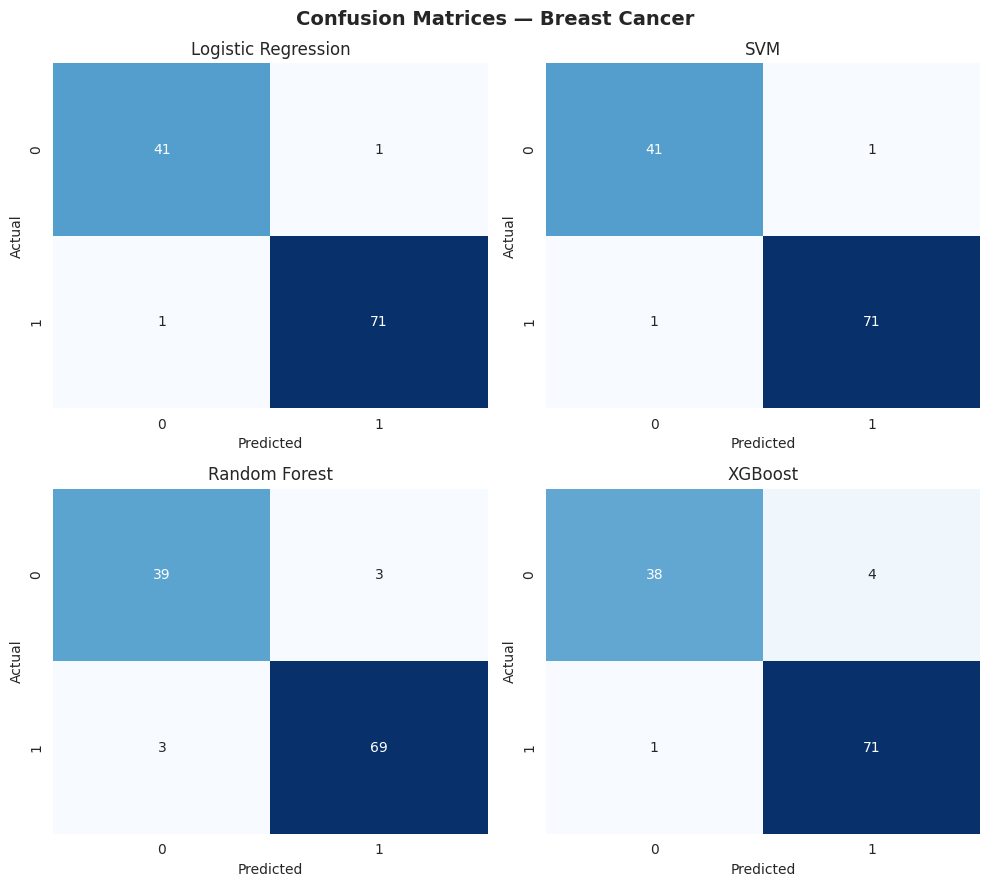

In [6]:
bc_results, bc_models, bc_scaler = run_pipeline(X_bc, y_bc, "Breast Cancer")


===== Heart Disease (samples=303, features=13) =====


              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest     0.820      0.762   0.970     0.853    0.906
                SVM     0.820      0.775   0.939     0.849    0.883
Logistic Regression     0.803      0.769   0.909     0.833    0.869
            XGBoost     0.787      0.750   0.909     0.822    0.850


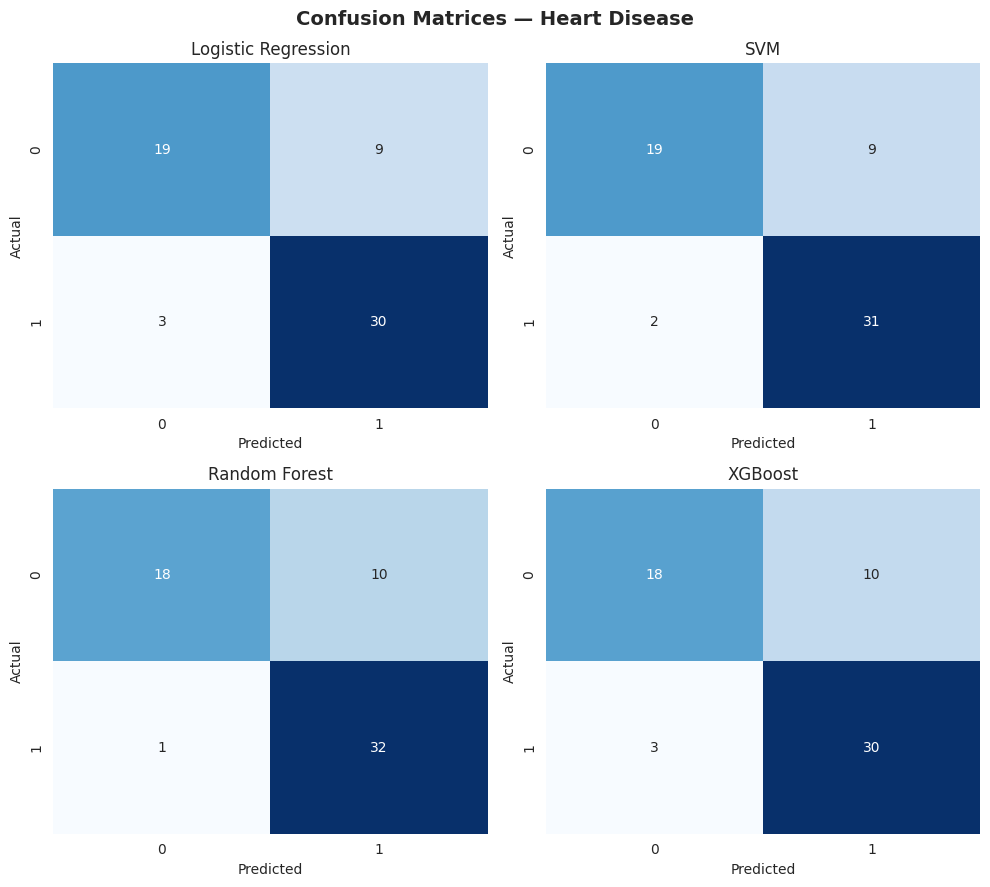

In [7]:
heart_results, heart_models, heart_scaler = run_pipeline(X_heart, y_heart, "Heart Disease")


===== Diabetes (samples=768, features=8) =====


              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
            XGBoost     0.753      0.667   0.593     0.627    0.807
                SVM     0.740      0.652   0.556     0.600    0.796
      Random Forest     0.734      0.644   0.537     0.586    0.817
Logistic Regression     0.708      0.600   0.500     0.545    0.813


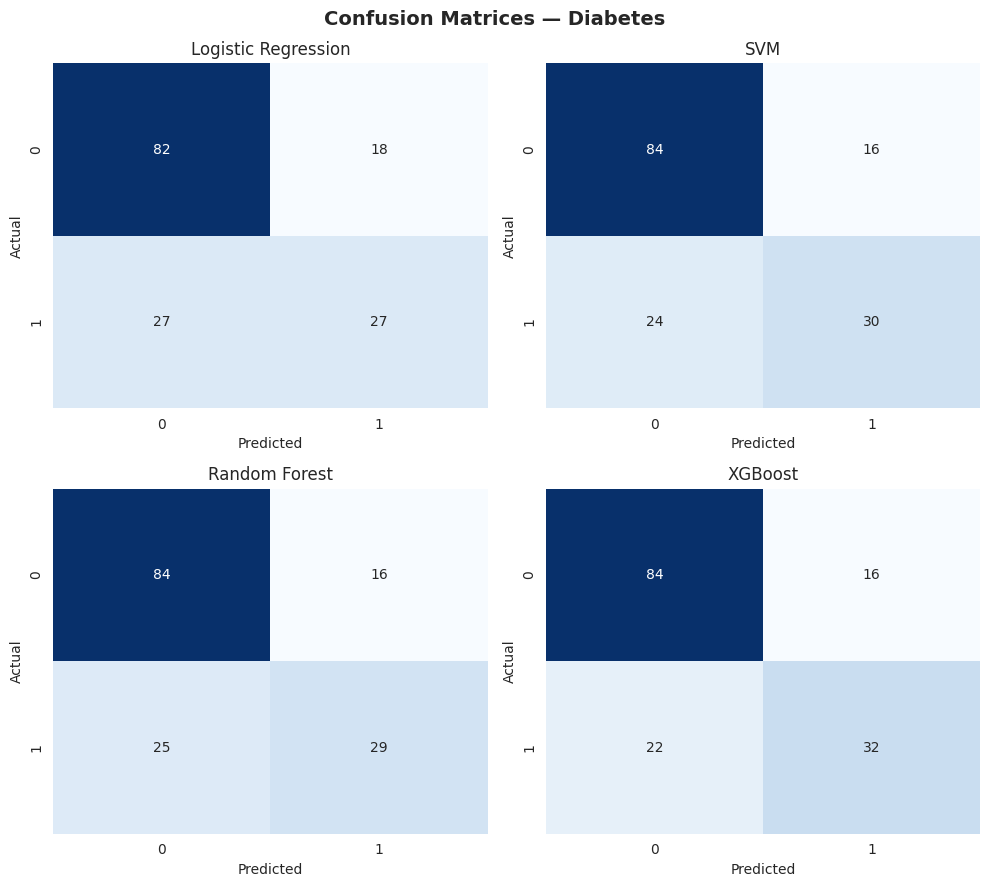

In [8]:
diab_results, diab_models, diab_scaler = run_pipeline(X_diab, y_diab, "Diabetes")

## 4. Compare all datasets/models

In [9]:
all_results = pd.concat([bc_results, heart_results, diab_results], ignore_index=True)
all_results.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Dataset
0,Logistic Regression,0.982,0.986,0.986,0.986,0.995,Breast Cancer
1,SVM,0.982,0.986,0.986,0.986,0.995,Breast Cancer
2,XGBoost,0.956,0.947,0.986,0.966,0.993,Breast Cancer
3,Random Forest,0.947,0.958,0.958,0.958,0.994,Breast Cancer
4,Random Forest,0.820,0.762,0.970,0.853,0.906,Heart Disease
5,SVM,0.820,0.775,0.939,0.849,0.883,Heart Disease
6,Logistic Regression,0.803,0.769,0.909,0.833,0.869,Heart Disease
7,XGBoost,0.787,0.750,0.909,0.822,0.850,Heart Disease
8,XGBoost,0.753,0.667,0.593,0.627,0.807,Diabetes
9,SVM,0.740,0.652,0.556,0.600,0.796,Diabetes


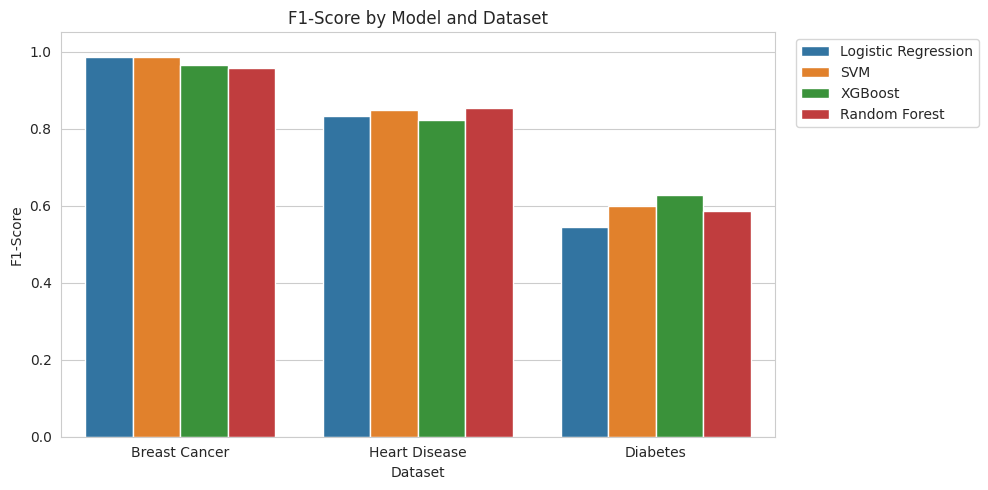

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=all_results, x="Dataset", y="F1-Score", hue="Model")
plt.title("F1-Score by Model and Dataset")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Conclusion

- **Breast Cancer** is the easiest problem (well-separated classes, clean data) — Logistic Regression / SVM reach ~98% accuracy.
- **Heart Disease** is moderately hard — Random Forest performs best (~82% accuracy, ROC-AUC ~0.91).
- **Diabetes** is the hardest of the three (noisier data, class imbalance) — XGBoost performs best (~75% accuracy, ROC-AUC ~0.81).

Across all three datasets, ensemble methods (Random Forest, XGBoost) tend to edge out simpler models on the noisier datasets, while linear models (Logistic Regression) do just as well when the data is cleanly separable, as in Breast Cancer.